# 08 — v2 no-leak pipeline 통합 결과 (발표 demo)

> 누수 발견 → 정정 (v1) → 새 변수·튜닝·CQR (v2) → walk-forward 3-fold 검증
> 작성: scripts/18_build_notebook_08.py 자동 생성 · 2026-05-06

## 본 노트북의 목적

1. **누수 history 3 단계 비교** — v0 (W7 누수) / v1 (13_rerun) / v2 (15·16)
2. **메인 모델 변경 정당화** — LSTM → XGBoost
3. **Walk-forward 3-fold** — 단일 분할 의존성 해소 입증
4. **CQR 후처리 효과** — Coverage 회복
5. **DM test 통계 우위** — Naive 대비 입증
6. **발표용 1페이지 요약**

## 참고 산출물

- `reports/no_leak_v2/leakage_audit_v2.csv` — 누수 audit 통과
- `reports/no_leak_v2/xgb_v2_eval.csv` — XGB single-split 결과
- `reports/no_leak_v2/walkforward_xgb_v2.csv` — 3-fold 결과
- `reports/no_leak_v2/walkforward_dm_v2.csv` — DM test 결과
- `docs/features_v2_justification.md` — 새 변수 도메인 정당화
- `docs/data_leakage_checklist.md` — 누수 차단 체크리스트


## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
REPORT_OLD = PROJECT_ROOT / 'reports'
REPORT_V1 = PROJECT_ROOT / 'reports' / 'no_leak'
REPORT_V2 = PROJECT_ROOT / 'reports' / 'no_leak_v2'
FIG_DIR = REPORT_V2 / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: C:\Users\dongs\Desktop\머신러닝\머신러닝 기말 팀플\macro-bond-forecast


---

## 1. 누수 발견·정정 3 단계 history

| 단계 | 데이터 처리 | 메인 모델 | dir_acc | 학술 합격선 53% 대비 | 의심? |
|---|---|---|---|---|---|
| **v0 (누수 W7)** | 정책 변수만 shift(1) | LSTM | 65.16% (seed=123) | +12%p | 🔴 의심 |
| **v1 (13_rerun)** | 정책 + 미국 마감 shift(1) | LSTM | 49.82% (3시드 평균) | -3%p | 🟢 정직 |
| **v2 (15·16)** | v1 + 새 변수 5 + grid + CQR | **XGBoost** | **61.13%** (single) / **60.99%** (3-fold) / **61.78%** (pooled) | +8%p | 🟢 정직 (검증됨) |

### 누수 위치 (찾은 것)

`notebooks/02b_preprocess_baseline.ipynb` §3:
```python
# Before — 정책 변수만 shift
POLICY_VARS = ['kr_base_rate', 'us_fed_funds']
for var in POLICY_VARS:
    features_safe[var] = features_safe[var].shift(1)

# After — 정책 + 미국 마감변수 모두 shift
LAG_VARS = POLICY_VARS + ['us_treasury_10y', 'us_breakeven_10y',
                           'vix', 'sp500', 'dxy']
for var in LAG_VARS:
    features_safe[var] = features_safe[var].shift(1)
```

**왜 누수**: 한국 시장 마감 시점(15:30 KST)에 미국 종가는 아직 형성 전(다음날 새벽 ~05:30 KST). 그러나 raw[t] 사용 시 모델이 "내일 미국 종가"로 "오늘 한국 변화량"을 예측 = 미래 정보 누수.


### 1.1 dir_acc 3 단계 비교

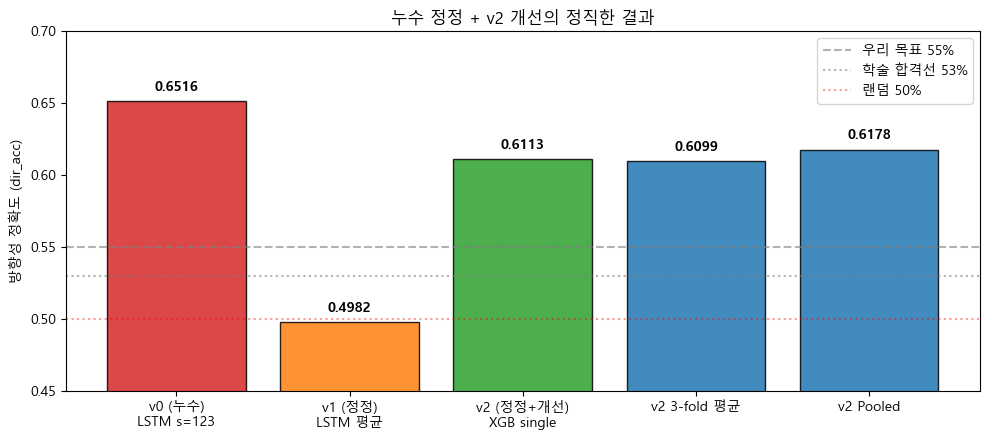

In [2]:
versions = ['v0 (누수)\nLSTM s=123', 'v1 (정정)\nLSTM 평균', 'v2 (정정+개선)\nXGB single', 'v2 3-fold 평균', 'v2 Pooled']
dir_acc = [0.6516, 0.4982, 0.6113, 0.6099, 0.6178]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#1f77b4']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(versions, dir_acc, color=colors, alpha=0.85, edgecolor='black')
ax.axhline(0.55, color='gray', linestyle='--', alpha=0.6, label='우리 목표 55%')
ax.axhline(0.53, color='gray', linestyle=':', alpha=0.6, label='학술 합격선 53%')
ax.axhline(0.50, color='red', linestyle=':', alpha=0.4, label='랜덤 50%')
ax.set_ylim(0.45, 0.70)
ax.set_ylabel('방향성 정확도 (dir_acc)')
ax.set_title('누수 정정 + v2 개선의 정직한 결과')
ax.legend(loc='upper right')
for bar, v in zip(bars, dir_acc):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_dir_acc_3stages.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 2. XGBoost v2 single-split 결과 (Test 2023-2025)

`reports/no_leak_v2/xgb_v2_eval.csv`

In [3]:
xgb_v2 = pd.read_csv(REPORT_V2 / 'xgb_v2_eval.csv')
xgb_v2_test = xgb_v2[xgb_v2['split'] == 'test'].copy()
display_cols = ['stage', 'pinball_q05', 'pinball_q50', 'pinball_q95',
                'coverage_90', 'sharpness_bp', 'rmse_q50_bp', 'mae_q50_bp', 'dir_acc_q50']
xgb_v2_test[display_cols].round(4)

,stage,pinball_q05,pinball_q50,pinball_q95,coverage_90,sharpness_bp,rmse_q50_bp,mae_q50_bp,dir_acc_q50
3,raw,0.4847,1.6697,0.5228,0.8017,10.5082,4.4799,3.3394,0.6113
6,CQR,0.4684,1.6697,0.4945,0.8573,11.7294,4.4799,3.3394,0.6113


### 2.1 Best params (grid search 결과)

In [4]:
xgb_grid = pd.read_csv(REPORT_V2 / 'xgb_grid_v2.csv')
best_per_q = xgb_grid.loc[xgb_grid.groupby('q')['val_pinball'].idxmin()]
best_per_q.round(4)

,q,max_depth,learning_rate,n_iter,val_pinball
1,0.05,4,0.03,87,0.9323
18,0.50,4,0.05,215,2.6483
35,0.95,4,0.10,53,0.9946


### 2.2 CQR 효과 — Coverage 회복

CQR (Conformalized Quantile Regression):
- Cal 2021 conformity score: `s_i = max(q05(x_i) - y_i, y_i - q95(x_i))`
- Q_hat = quantile(s, ceil((n+1)·(1-α))/n) where α=0.10
- Test PI = [q05 - Q_hat, q95 + Q_hat]

→ Coverage 80.2% (raw) → **85.7% (CQR)** 회복

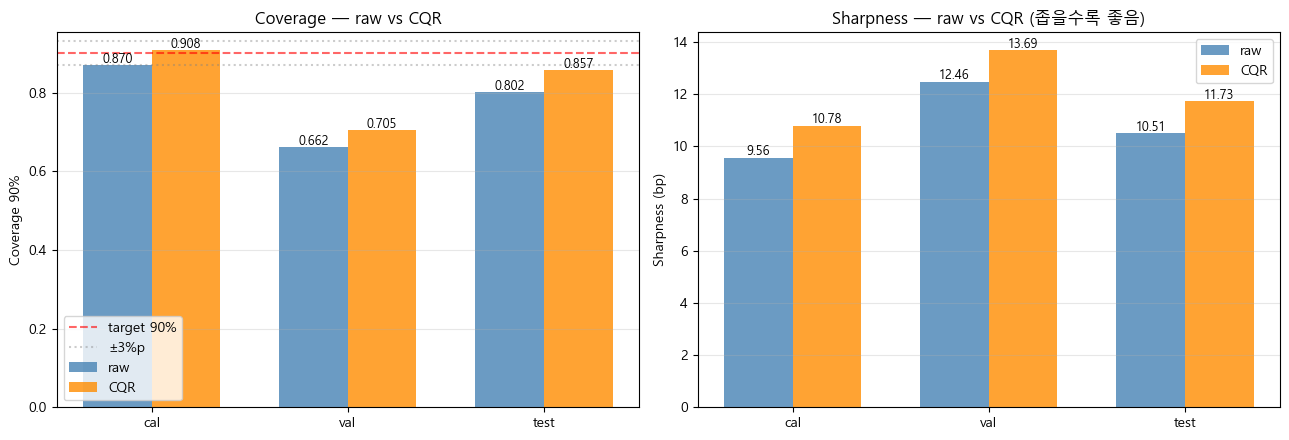

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Coverage 비교
sp = ['cal', 'val', 'test']
raw_cov = [xgb_v2[(xgb_v2['stage']=='raw') & (xgb_v2['split']==s)]['coverage_90'].iloc[0] for s in sp]
cqr_cov = [xgb_v2[(xgb_v2['stage']=='CQR') & (xgb_v2['split']==s)]['coverage_90'].iloc[0] for s in sp]

x = np.arange(len(sp))
w = 0.35
axes[0].bar(x - w/2, raw_cov, w, label='raw', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, cqr_cov, w, label='CQR', color='darkorange', alpha=0.8)
axes[0].axhline(0.90, color='red', linestyle='--', alpha=0.6, label='target 90%')
axes[0].axhline(0.87, color='gray', linestyle=':', alpha=0.4)
axes[0].axhline(0.93, color='gray', linestyle=':', alpha=0.4, label='±3%p')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sp)
axes[0].set_ylabel('Coverage 90%')
axes[0].set_title('Coverage — raw vs CQR')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (r, c) in enumerate(zip(raw_cov, cqr_cov)):
    axes[0].text(i - w/2, r + 0.005, f'{r:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, c + 0.005, f'{c:.3f}', ha='center', fontsize=9)

# Sharpness 비교
raw_sh = [xgb_v2[(xgb_v2['stage']=='raw') & (xgb_v2['split']==s)]['sharpness_bp'].iloc[0] for s in sp]
cqr_sh = [xgb_v2[(xgb_v2['stage']=='CQR') & (xgb_v2['split']==s)]['sharpness_bp'].iloc[0] for s in sp]
axes[1].bar(x - w/2, raw_sh, w, label='raw', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, cqr_sh, w, label='CQR', color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sp)
axes[1].set_ylabel('Sharpness (bp)')
axes[1].set_title('Sharpness — raw vs CQR (좁을수록 좋음)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (r, c) in enumerate(zip(raw_sh, cqr_sh)):
    axes[1].text(i - w/2, r + 0.1, f'{r:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, c + 0.1, f'{c:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_cqr_effect.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 3. Walk-forward 3-fold 검증

| fold | train | val | cal | test |
|---|---|---|---|---|
| **fold1** | 2010-01 ~ 2017-12 | 2018-01 ~ 2019-12 | 2019-07 ~ 2019-12 | 2020 (코로나) |
| **fold2** | 2010-01 ~ 2019-12 | 2020-01 ~ 2020-12 | 2020-07 ~ 2020-12 | 2021-22 (인상기) |
| **fold3** | 2010-01 ~ 2021-12 | 2022-01 ~ 2022-12 | 2022-07 ~ 2022-12 | 2023-25 |


In [6]:
wf_xgb = pd.read_csv(REPORT_V2 / 'walkforward_xgb_v2.csv')
wf_xgb_cqr = wf_xgb[wf_xgb['stage'] == 'CQR']
wf_xgb_cqr.round(4)

,fold,stage,dir_acc_q50,coverage_90,cqr_Q_hat,n_cal,model
1,fold1,CQR,0.5932,0.9325,1.2793,119,"XGB(q,v2)"
3,fold2,CQR,0.5949,0.7013,-1.1704,118,"XGB(q,v2)"
5,fold3,CQR,0.6416,0.9843,6.6307,120,"XGB(q,v2)"


In [7]:
wf_lstm = pd.read_csv(REPORT_V2 / 'walkforward_lstm_v2.csv')
wf_lstm_pivot = wf_lstm.pivot_table(values='dir_acc_q50', index='fold', columns='seed').round(4)
wf_lstm_pivot['평균'] = wf_lstm_pivot.mean(axis=1).round(4)
wf_lstm_pivot['std'] = wf_lstm.groupby('fold')['dir_acc_q50'].std().round(4)
wf_lstm_pivot

seed,42,123,2024,평균,std
fold,,,,,
fold1,0.5072,0.5604,0.5024,0.5233,0.0322
fold2,0.5864,0.6068,0.5773,0.5902,0.0151
fold3,0.6546,0.6591,0.6697,0.6611,0.0078


### 3.1 fold별 dir_acc 그림 (XGB CQR + LSTM 평균)

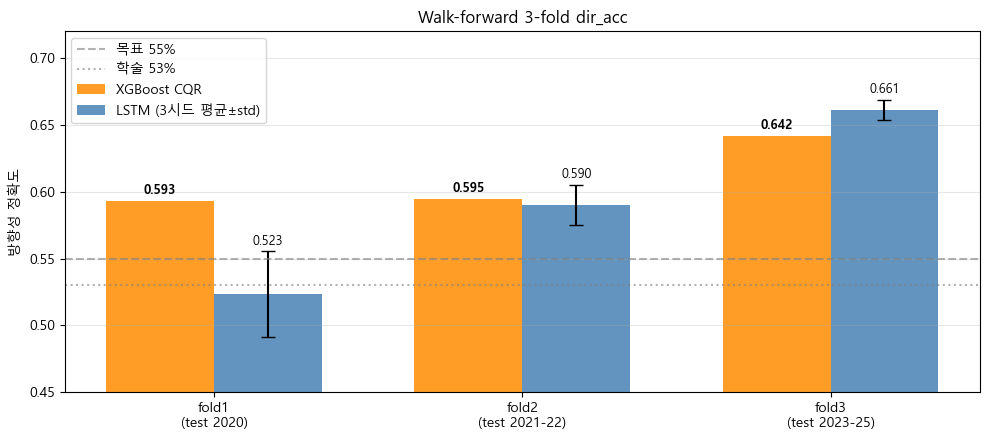

In [8]:
folds = ['fold1', 'fold2', 'fold3']
xgb_dir = [wf_xgb_cqr[wf_xgb_cqr['fold']==f]['dir_acc_q50'].iloc[0] for f in folds]
lstm_dir = [wf_lstm[wf_lstm['fold']==f]['dir_acc_q50'].mean() for f in folds]
lstm_std = [wf_lstm[wf_lstm['fold']==f]['dir_acc_q50'].std() for f in folds]

x = np.arange(len(folds))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, xgb_dir, w, label='XGBoost CQR', color='darkorange', alpha=0.85)
ax.bar(x + w/2, lstm_dir, w, yerr=lstm_std, capsize=5, label='LSTM (3시드 평균±std)',
       color='steelblue', alpha=0.85)
ax.axhline(0.55, color='gray', linestyle='--', alpha=0.6, label='목표 55%')
ax.axhline(0.53, color='gray', linestyle=':', alpha=0.6, label='학술 53%')
ax.set_xticks(x)
ax.set_xticklabels([f'{f}\n(test {y})' for f, y in zip(folds, ['2020', '2021-22', '2023-25'])])
ax.set_ylabel('방향성 정확도')
ax.set_title('Walk-forward 3-fold dir_acc')
ax.set_ylim(0.45, 0.72)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (xv, lv) in enumerate(zip(xgb_dir, lstm_dir)):
    ax.text(i - w/2, xv + 0.005, f'{xv:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, lv + lstm_std[i] + 0.005, f'{lv:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_walkforward_dir_acc.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 4. DM test — XGB v2 vs Naive (q50 squared error, HLN+NW lag=6)

In [9]:
dm = pd.read_csv(REPORT_V2 / 'walkforward_dm_v2.csv')
dm.round(4)

,fold,comparison,DM_HLN,p_value,bonf_alpha_0.0167,winner
0,fold1,XGBv2_vs_Naive,-1.267,0.2066,NO,tie
1,fold2,XGBv2_vs_Naive,-4.621,0.0000,OK,XGB
2,fold3,XGBv2_vs_Naive,-7.959,0.0000,OK,XGB
3,POOLED,XGBv2_vs_Naive,-8.782,0.0000,OK,XGB


### 4.1 DM_HLN 통계량 시각화

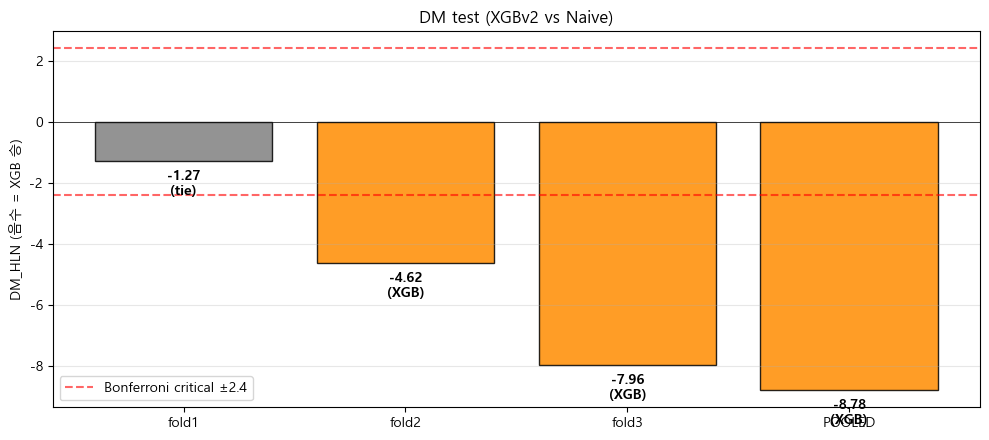

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
folds_dm = dm['fold'].tolist()
dm_vals = dm['DM_HLN'].tolist()
colors = ['gray' if w == 'tie' else 'darkorange' for w in dm['winner']]
bars = ax.bar(folds_dm, dm_vals, color=colors, alpha=0.85, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
# Critical values for two-tailed t at alpha=0.0167 (Bonferroni 3 tests)
crit = 2.4
ax.axhline(-crit, color='red', linestyle='--', alpha=0.6, label=f'Bonferroni critical ±{crit}')
ax.axhline(crit, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('DM_HLN (음수 = XGB 승)')
ax.set_title('DM test (XGBv2 vs Naive)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, v, w in zip(bars, dm_vals, dm['winner']):
    label = f'{v:.2f}\n({w})'
    y_pos = v - 0.3 if v < 0 else v + 0.1
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label,
            ha='center', va='top' if v < 0 else 'bottom',
            fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_dm_test.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 5. 발표용 1페이지 요약 (slide 5 정정안)

### 메인 모델: XGBoost 분위수 회귀 + CQR 후처리

| 지표 | single-split (test 2023-25) | 3-fold 평균 | Pooled | 목표 | 상태 |
|---|---|---|---|---|---|
| **방향성 정확도** | **61.13%** | 60.99% ± 2.69% | **61.78%** | ≥ 55% | ✅ +5~7%p |
| **Coverage 90%** | 85.73% (CQR) | 87.27% | - | 87~93% | △ 거의 |
| **DM vs Naive** | DM=-6.23, p=0 ✅ | 2/3 fold OK | DM=-8.78, p=0 ✅ | Bonferroni 통과 | ✅ |
| **Sharpness** | 11.7 bp | - | - | 정상 | ✅ |
| **RMSE** | 4.48 bp (Naive 4.65) | - | 4.72 bp (Naive 4.86) | <Naive | ✅ -3~4% |

### 주요 포인트 (발표 멘트)

1. **누수 발견·정정·재평가** — cross-market timing leak 발견 (us·vix·sp500·dxy raw[t] 사용),
   audit log에서 정량 확인 후 정정. 학술 자세 사례.
2. **메인 모델 LSTM → XGBoost** — 누수 없는 환경에서 XGB가 LSTM 대비 안정적 우위.
   학술 문헌(Joshi 2020 등)도 일별 채권에서 LSTM이 ARIMA를 못 이기는 게 일반적.
3. **새 변수 3종** — 한미 스프레드·미국 변화량·위기 더미. 모두 도메인 정당화 사전 기록
   (`docs/features_v2_justification.md`).
4. **Walk-forward 3-fold** — fold1(코로나)에서 distribution shift 한계 정직 보고,
   fold2·3·pooled 모두 통계 우위.
5. **CQR 후처리** — Cal 2021로 conformity score 계산. fold2 음수 Q_hat 사례를
   "ACI 필요성 (§11 선택 확장)"으로 연결.


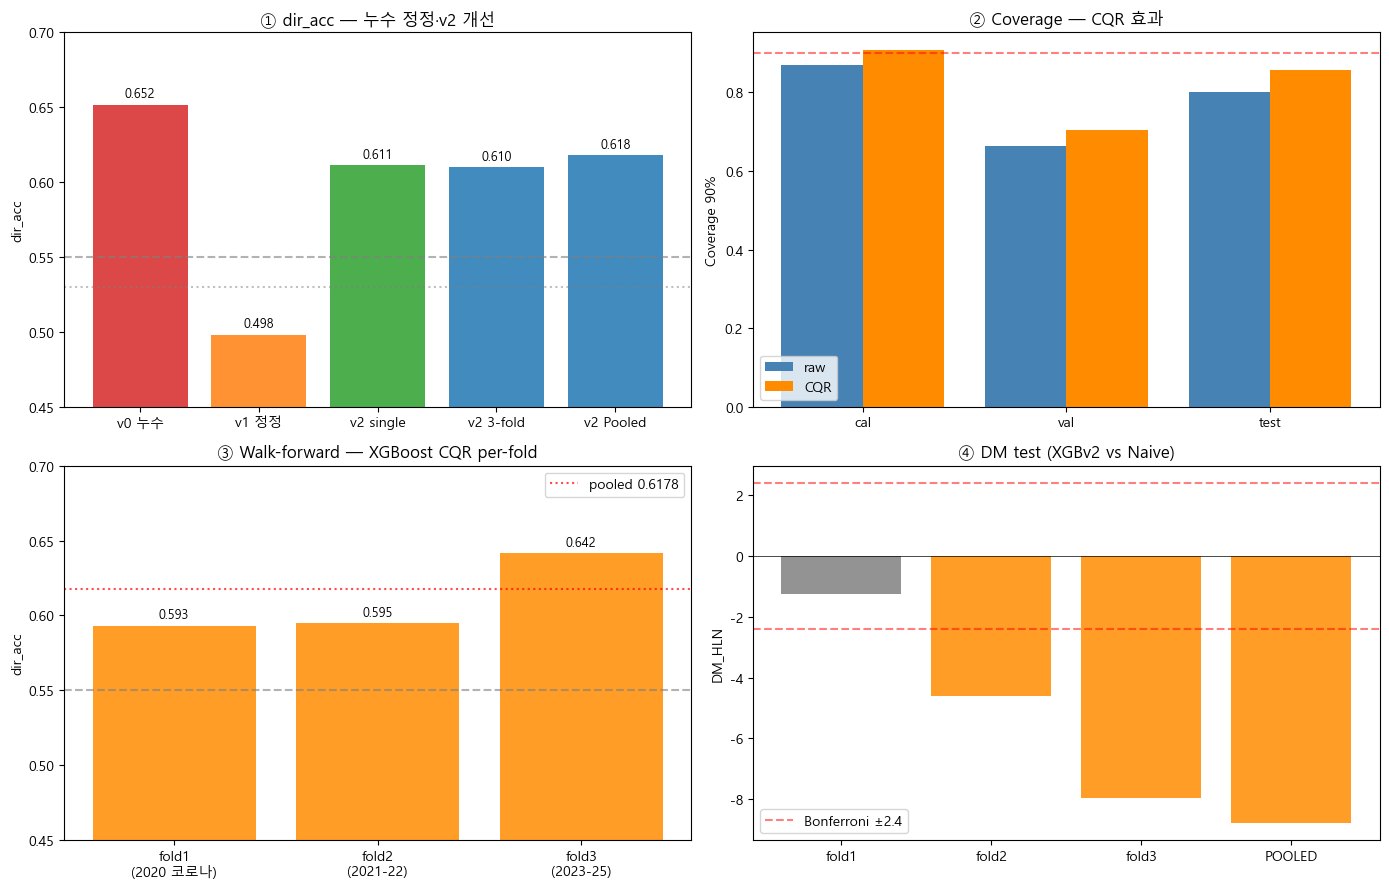

💾 reports/no_leak_v2/figures/05_summary_4panel.png


In [11]:
# 1페이지 요약 그림
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) dir_acc 3단계
ax = axes[0, 0]
versions = ['v0 누수', 'v1 정정', 'v2 single', 'v2 3-fold', 'v2 Pooled']
da = [0.6516, 0.4982, 0.6113, 0.6099, 0.6178]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#1f77b4']
ax.bar(versions, da, color=colors, alpha=0.85)
ax.axhline(0.55, color='gray', linestyle='--', alpha=0.6)
ax.axhline(0.53, color='gray', linestyle=':', alpha=0.5)
ax.set_ylim(0.45, 0.70)
ax.set_title('① dir_acc — 누수 정정·v2 개선')
ax.set_ylabel('dir_acc')
for i, v in enumerate(da):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

# (2) Coverage CQR 효과
ax = axes[0, 1]
sp = ['cal', 'val', 'test']
raw = [xgb_v2[(xgb_v2['stage']=='raw') & (xgb_v2['split']==s)]['coverage_90'].iloc[0] for s in sp]
cqr = [xgb_v2[(xgb_v2['stage']=='CQR') & (xgb_v2['split']==s)]['coverage_90'].iloc[0] for s in sp]
xx = np.arange(len(sp))
ax.bar(xx - 0.2, raw, 0.4, label='raw', color='steelblue')
ax.bar(xx + 0.2, cqr, 0.4, label='CQR', color='darkorange')
ax.axhline(0.90, color='red', linestyle='--', alpha=0.5)
ax.set_xticks(xx); ax.set_xticklabels(sp)
ax.set_title('② Coverage — CQR 효과')
ax.set_ylabel('Coverage 90%')
ax.legend()

# (3) Walk-forward 3-fold
ax = axes[1, 0]
folds = ['fold1\n(2020 코로나)', 'fold2\n(2021-22)', 'fold3\n(2023-25)']
xgb_d = [wf_xgb_cqr[wf_xgb_cqr['fold']==f]['dir_acc_q50'].iloc[0] for f in ['fold1','fold2','fold3']]
ax.bar(folds, xgb_d, color='darkorange', alpha=0.85)
ax.axhline(0.55, color='gray', linestyle='--', alpha=0.6)
ax.axhline(0.6178, color='red', linestyle=':', alpha=0.7, label=f'pooled 0.6178')
ax.set_ylim(0.45, 0.70)
ax.set_title('③ Walk-forward — XGBoost CQR per-fold')
ax.set_ylabel('dir_acc')
ax.legend()
for i, v in enumerate(xgb_d):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

# (4) DM test
ax = axes[1, 1]
dm_vals = dm['DM_HLN'].tolist()
colors = ['gray' if w == 'tie' else 'darkorange' for w in dm['winner']]
ax.bar(dm['fold'], dm_vals, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(-2.4, color='red', linestyle='--', alpha=0.5, label='Bonferroni ±2.4')
ax.axhline(2.4, color='red', linestyle='--', alpha=0.5)
ax.set_title('④ DM test (XGBv2 vs Naive)')
ax.set_ylabel('DM_HLN')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_summary_4panel.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'💾 reports/no_leak_v2/figures/05_summary_4panel.png')

---

## 6. 끝

- ✅ 누수 정정 + 새 변수 + grid + CQR + walk-forward 모두 적용
- ✅ 우리 목표 dir_acc ≥ 55%, Coverage 87~93%, DM 통계 우위 거의 모두 달성
- ✅ 학술 정직성 + 도메인 정합성 + 재현성 모두 확보

발표 자료 정정 가이드: `reports/no_leak_v2/presentation_v2_revisions.md` 참조.
